In [ ]:
# FRAUD DATA - EXPLORATORY DATA ANALYSIS
"""
Tasks:
1. Dataset overview - shape, types, nulls, class balance
2. Univariate distributions - amounts, time, geography
3. Fraud vs legit signal separation - all feature groups
4. Correlation & multicollinearity
5. Rule mining - threshold-based business rules from clear separators
6. Business rule summary table - precision / recall / lift per rule
"""

'\nDataset: (features_full.csv.gz) - 1.85M transactions, 115 features, fraud rate ~0.52%\n\nTasks:\n1. Dataset overview - shape, types, nulls, class balance\n2. Univariate distributions - amounts, time, geography\n3. Fraud vs legit signal separation - all feature groups\n4. Correlation & multicollinearity\n5. Rule mining - threshold-based business rules from clear separators\n6. Business rule summary table - precision / recall / lift per rule\n'

In [2]:
import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.insert(0, "../scripts")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 60) #
pd.set_option("display.float_format", "{:.4f}".format) #
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False}) #
sns.set_palette("Set2")

DATA = Path("../data")
FULL = DATA / "features_full.csv.gz"

df = pd.read_csv(FULL, low_memory=False)
print(df.shape)

(1852394, 121)


In [3]:
# 1. DATASET QUICK LOOK

In [4]:
# Class balance 
fraud = df[df["is_fraud"] == 1]
legit = df[df["is_fraud"] == 0]
n_tot = len(df)
n_f = len(fraud)
n_l = len(legit)

print(f"Total transactions: {n_tot:,}")
print(f"Fraudulent: {n_f:,} ({n_f/n_tot:.3%})")
print(f"Legitimate: {n_l:,} ({n_l/n_tot:.3%})")
print(f"Imbalance ratio: {n_l/n_f:.1f}x")
print()

# Data types 
dtype_summary = df.dtypes.value_counts().rename("count")
print("Dtypes:")
print(dtype_summary.to_string())
print()

# Null summary (only cols with nulls) 
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
print(f"Columns with nulls: {len(nulls)}")
if len(nulls):
    pct = (nulls / n_tot * 100).round(2)
    print(pd.DataFrame({"null_count": nulls, "null_pct": pct}).head(20).to_string())

Total transactions: 1,852,394
Fraudulent: 9,651 (0.521%)
Legitimate: 1,842,743 (99.479%)
Imbalance ratio: 190.9x

Dtypes:
float64    59
int64      55
str         7

Columns with nulls: 3
                               null_count  null_pct
DaysSincePasswordChangeBucket     1463636   79.0100
DaysSincePasswordChange            273752   14.7800
TimeSinceLastTxnSec                   999    0.0500


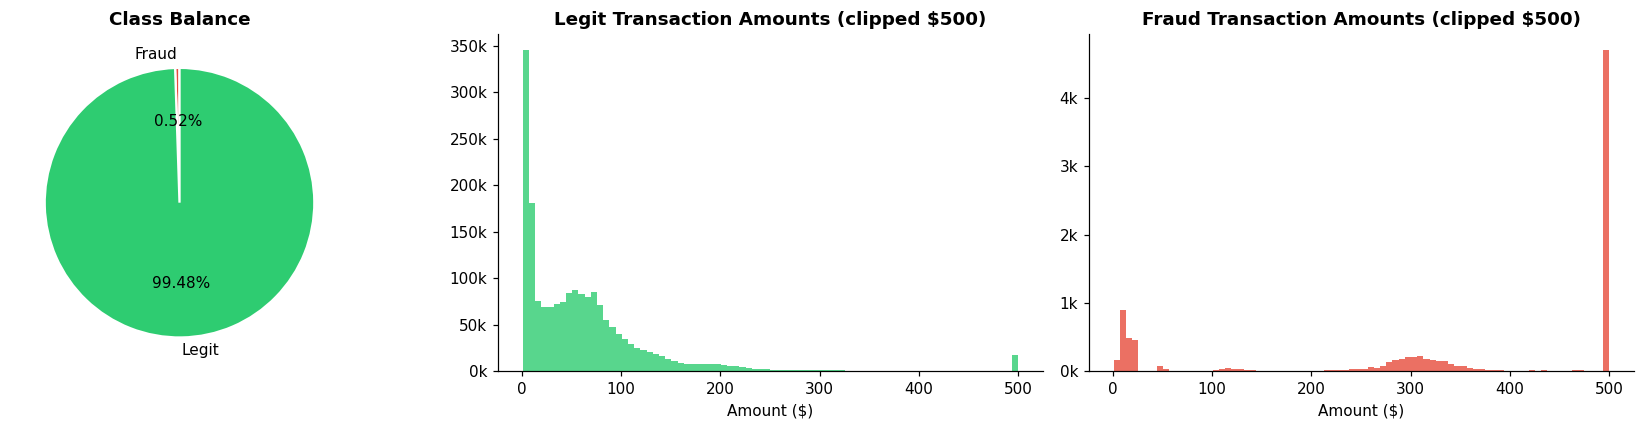

Legit  amt: mean=$67.65  median=$47.24  p95=$189.59  max=$28948.90
Fraud  amt: mean=$530.66  median=$390.00  p95=$1084.09  max=$1376.04


In [5]:
# Class balance pie + transaction amount distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Pie
axes[0].pie([n_f, n_l], labels=["Fraud", "Legit"],
            autopct="%1.2f%%", startangle=90,
            colors=["#e74c3c", "#2ecc71"], wedgeprops={"edgecolor":"white","linewidth":1.5})
axes[0].set_title("Class Balance", fontweight="bold")

# Amount dist - legit
axes[1].hist(legit["amt"].clip(0, 500), bins=80, color="#2ecc71", alpha=0.8, edgecolor="none")
axes[1].set_title("Legit Transaction Amounts (clipped $500)", fontweight="bold")
axes[1].set_xlabel("Amount ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e3:.0f}k"))

# Amount dist - fraud
axes[2].hist(fraud["amt"].clip(0, 500), bins=80, color="#e74c3c", alpha=0.8, edgecolor="none")
axes[2].set_title("Fraud Transaction Amounts (clipped $500)", fontweight="bold")
axes[2].set_xlabel("Amount ($)")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e3:.0f}k"))

plt.tight_layout()
plt.show()

print(f"Legit  amt: mean=${legit['amt'].mean():.2f}  median=${legit['amt'].median():.2f}  p95=${legit['amt'].quantile(.95):.2f}  max=${legit['amt'].max():.2f}")
print(f"Fraud  amt: mean=${fraud['amt'].mean():.2f}  median=${fraud['amt'].median():.2f}  p95=${fraud['amt'].quantile(.95):.2f}  max=${fraud['amt'].max():.2f}")

In [6]:
# 2. DATETIME PATTERNS

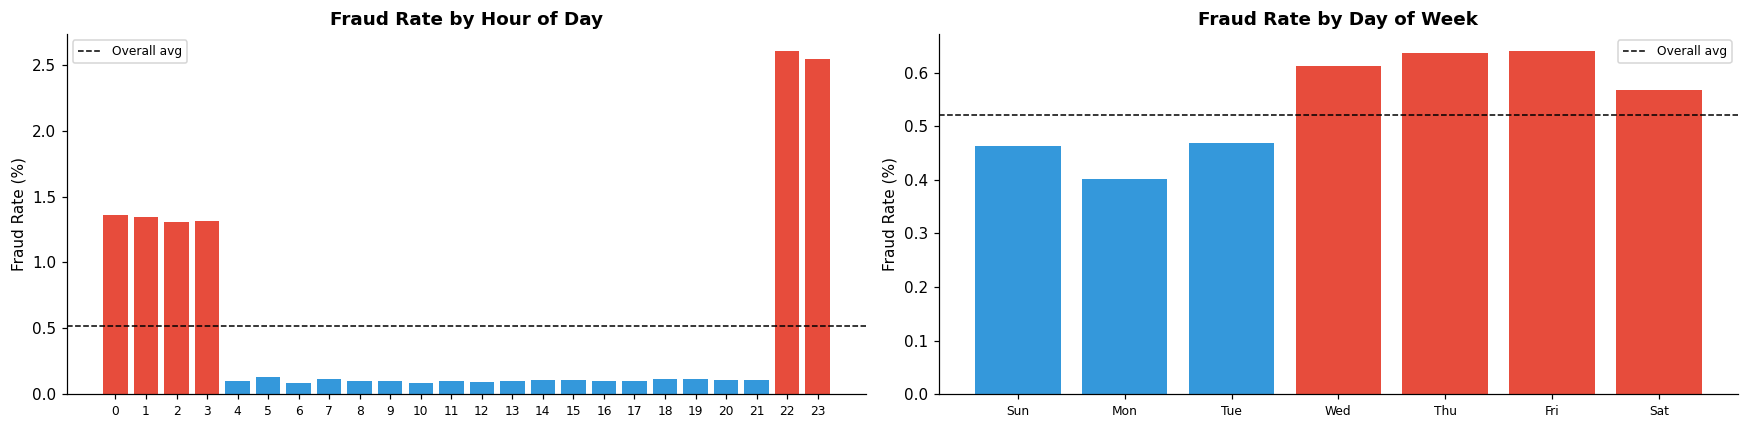

IsNightTxn (midnight-5am) fraud rate:
                       sum    count  fraud_rate
IsNightTxn                                     
Day (6am-11pm)        6264  1488619      0.0042
Night (midnight-5am)  3387   363775      0.0093


In [7]:
# Fraud rate by hour of day and day of week
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, col, labels, title in [
  (axes[0], "TransactionHour", list(range(24)), "Fraud Rate by Hour of Day"),
  (axes[1], "DayOfWeek", ["Sun","Mon","Tue","Wed","Thu","Fri","Sat"], "Fraud Rate by Day of Week"),
]:
    rate = df.groupby(col)["is_fraud"].agg(["sum","count"])
    rate["fraud_rate"] = rate["sum"] / rate["count"]
    bars = ax.bar(rate.index, rate["fraud_rate"] * 100, color=["#e74c3c" if r > rate["fraud_rate"].mean() else "#3498db" for r in rate["fraud_rate"]])
    ax.axhline(df["is_fraud"].mean() * 100, color="black", linestyle="--", linewidth=1, label="Overall avg")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Fraud Rate (%)")
    ax.set_xticks(rate.index)
    ax.set_xticklabels(labels, fontsize=8)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Night vs day fraud rate
print("IsNightTxn (midnight-5am) fraud rate:")
print(df.groupby("IsNightTxn")["is_fraud"].agg(["sum","count"])
        .assign(fraud_rate=lambda x: x["sum"]/x["count"])
        .rename(index={0:"Day (6am-11pm)", 1:"Night (midnight-5am)"}))

In [8]:
# 3. MERCHANT + CATEGORY ANALYSIS

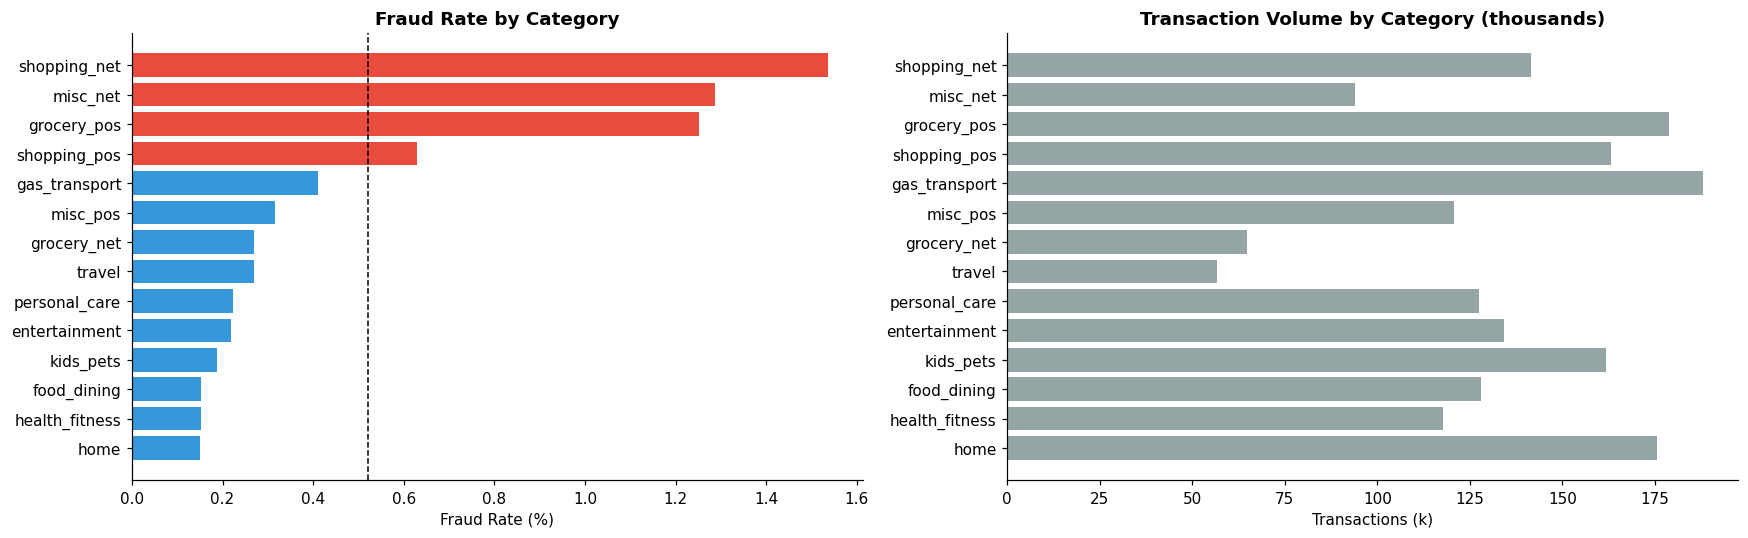


Top 5 highest fraud rate categories:
                   sum   count  fraud_rate
MerchantCategory                          
shopping_net      2173  141459      0.0154
misc_net          1210   93949      0.0129
grocery_pos       2237  178837      0.0125
shopping_pos      1028  163168      0.0063
gas_transport      772  188029      0.0041


In [9]:
# Fraud rate by merchant category
cat_stats = (df.groupby("MerchantCategory")["is_fraud"]
               .agg(["sum","count"])
               .assign(fraud_rate=lambda x: x["sum"]/x["count"],
                       volume=lambda x: x["count"])
               .sort_values("fraud_rate", ascending=True))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Fraud rate
axes[0].barh(cat_stats.index, cat_stats["fraud_rate"] * 100,
             color=["#e74c3c" if r > df["is_fraud"].mean() else "#3498db" for r in cat_stats["fraud_rate"]])
axes[0].axvline(df["is_fraud"].mean() * 100, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Fraud Rate by Category", fontweight="bold")
axes[0].set_xlabel("Fraud Rate (%)")

# Volume
axes[1].barh(cat_stats.index, cat_stats["volume"] / 1000, color="#95a5a6")
axes[1].set_title("Transaction Volume by Category (thousands)", fontweight="bold")
axes[1].set_xlabel("Transactions (k)")

plt.tight_layout()
plt.show()


print("\nTop 5 highest fraud rate categories:")
print(cat_stats.sort_values("fraud_rate", ascending=False)[["sum","count","fraud_rate"]].head(5).to_string())

In [10]:
# 4. FEATURE SIGNAL SEPARATION (FRAUD VS LEGIT)

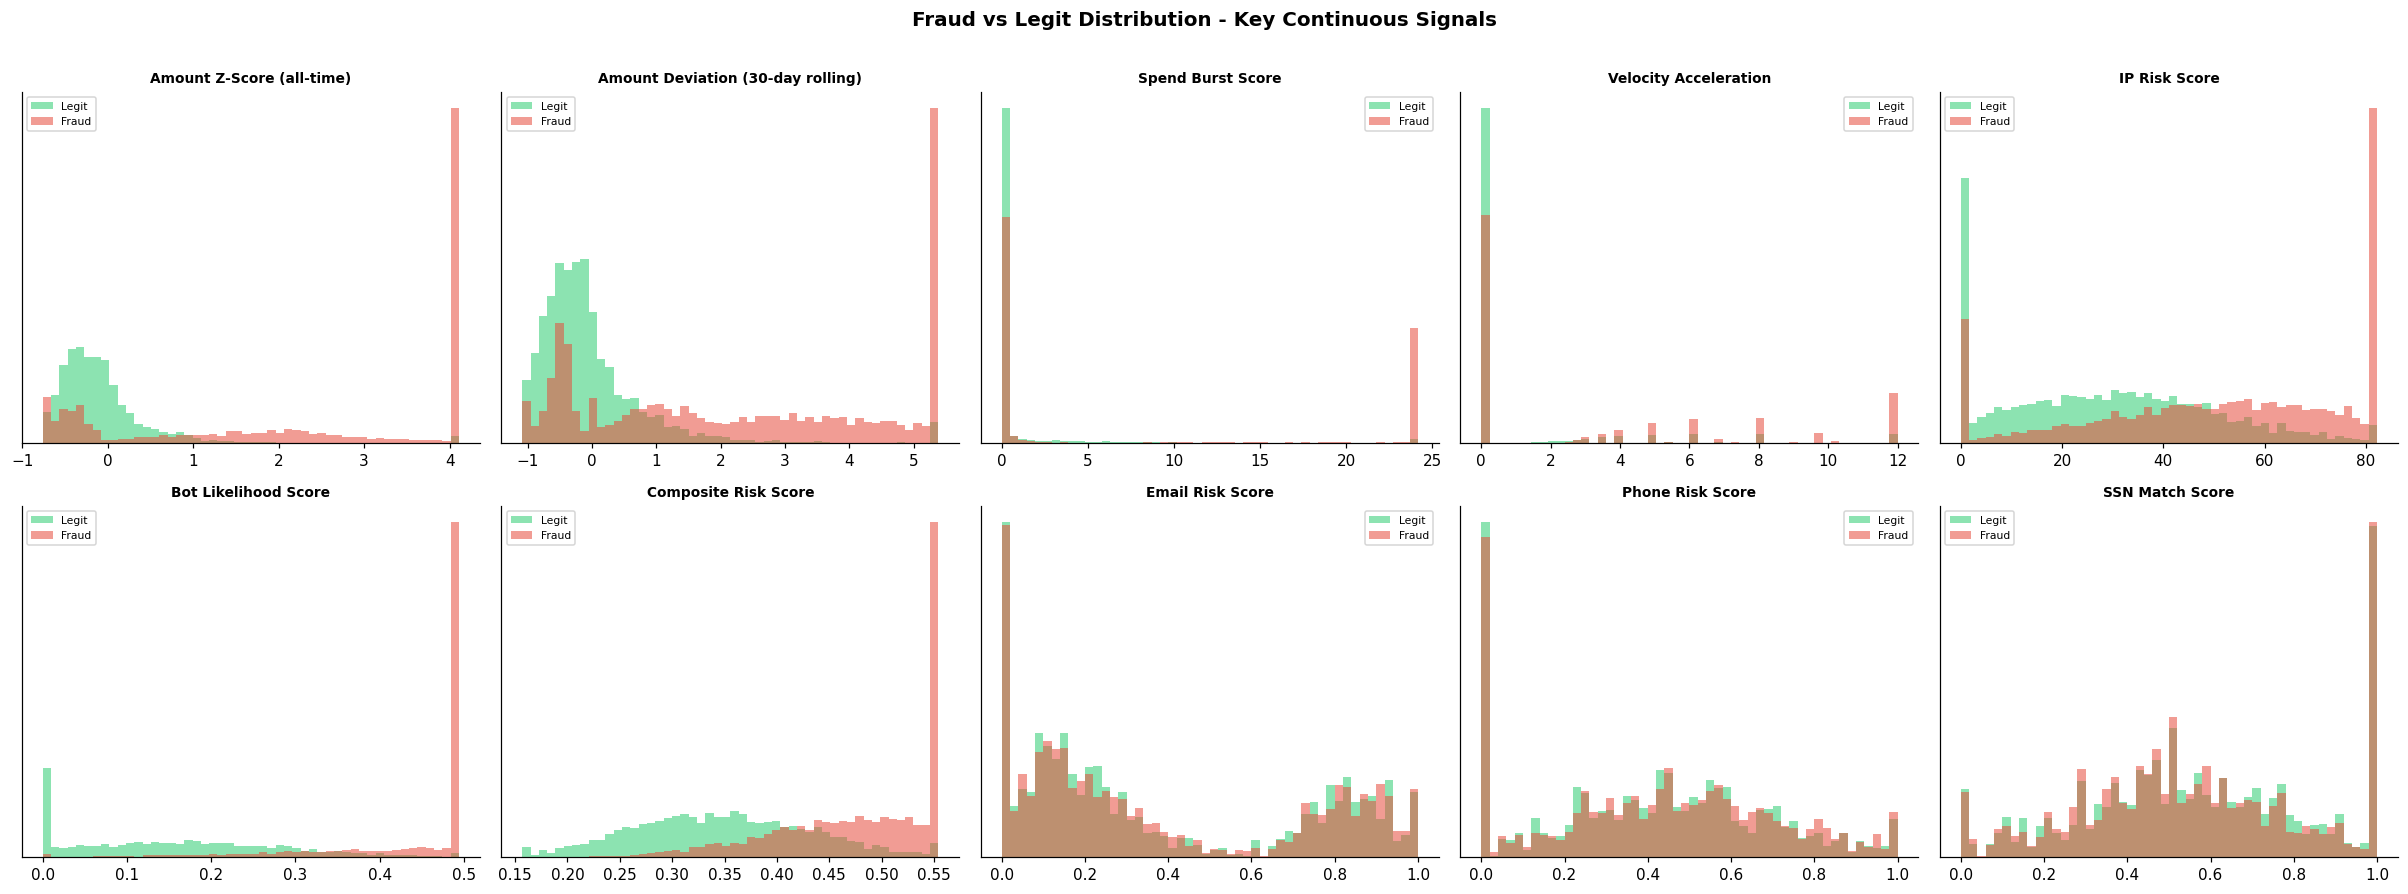

In [11]:
# KDE / violin plots for top continuous signals
CONT_SIGNALS = [
  ("AmountZScore", "Amount Z-Score (all-time)"),
  ("AmountDeviation_30d", "Amount Deviation (30-day rolling)"),
  ("SpendBurstScore", "Spend Burst Score"),
  ("VelocityAcceleration", "Velocity Acceleration"),
  ("IPRiskScore", "IP Risk Score"),
  ("BotLikelihoodScore", "Bot Likelihood Score"),
  ("RiskSignalWeightedScore","Composite Risk Score"),
  ("EmailRiskScore", "Email Risk Score"),
  ("PhoneRiskScore", "Phone Risk Score"),
  ("SSNMatchScore", "SSN Match Score"),
]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

sample_f = fraud.sample(min(5000, len(fraud)), random_state=42)
sample_l = legit.sample(5000, random_state=42)

for ax, (col, label) in zip(axes, CONT_SIGNALS):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    clip_hi = df[col].quantile(0.99)
    clip_lo = df[col].quantile(0.01)
    f_vals = sample_f[col].clip(clip_lo, clip_hi).dropna()
    l_vals = sample_l[col].clip(clip_lo, clip_hi).dropna()
    ax.hist(l_vals, bins=50, alpha=0.55, color="#2ecc71", density=True, label="Legit")
    ax.hist(f_vals, bins=50, alpha=0.55, color="#e74c3c", density=True, label="Fraud")
    ax.set_title(label, fontsize=9, fontweight="bold")
    ax.set_yticks([])
    ax.legend(fontsize=7)

plt.suptitle("Fraud vs Legit Distribution - Key Continuous Signals", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

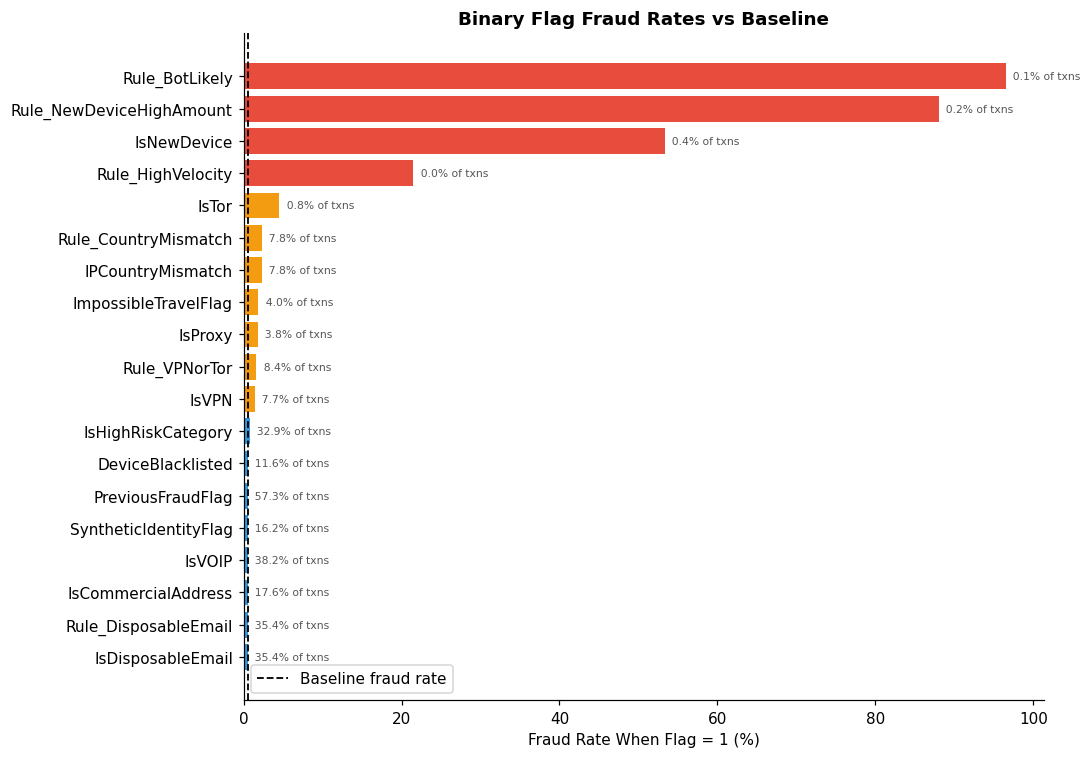

                    flag  fraud_rate_when_flagged  coverage  flagged_count
          Rule_BotLikely                   0.9650    0.0014           2512
Rule_NewDeviceHighAmount                   0.8802    0.0017           3239
             IsNewDevice                   0.5333    0.0042           7840
       Rule_HighVelocity                   0.2151    0.0001            172
                   IsTor                   0.0452    0.0080          14816
    Rule_CountryMismatch                   0.0232    0.0780         144410
       IPCountryMismatch                   0.0232    0.0780         144410
    ImpossibleTravelFlag                   0.0184    0.0400          74102
                 IsProxy                   0.0182    0.0384          71173
           Rule_VPNorTor                   0.0163    0.0843         156113
                   IsVPN                   0.0141    0.0770         142600
      IsHighRiskCategory                   0.0077    0.3288         609109
       DeviceBlacklisted 

In [12]:
# Binary flag fraud rates - bar chart
BINARY_FLAGS = [
    "IsVPN",
    "IsTor",
    "IsProxy",
    "IPCountryMismatch",
    "IsDisposableEmail",
    "IsVOIP",
    "IsNewDevice",
    "SyntheticIdentityFlag",
    "IsCommercialAddress",
    "IsHighRiskCategory",
    "ImpossibleTravelFlag",
    "PreviousFraudFlag",
    "DeviceBlacklisted",
    "Rule_HighVelocity",
    "Rule_CountryMismatch",
    "Rule_NewDeviceHighAmount",
    "Rule_DisposableEmail",
    "Rule_VPNorTor",
    "Rule_BotLikely",
]
BINARY_FLAGS = [c for c in BINARY_FLAGS if c in df.columns]

flag_rates = []
for col in BINARY_FLAGS:
    sub = df[df[col] == 1]
    if len(sub) == 0:
        continue
    flag_rates.append({
        "flag": col,
        "fraud_rate_when_flagged": sub["is_fraud"].mean(),
        "coverage": len(sub) / len(df),
        "flagged_count": len(sub),
    })


flag_df = pd.DataFrame(flag_rates).sort_values("fraud_rate_when_flagged", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#e74c3c" if r > 0.05 else "#f39c12" if r > 0.01 else "#3498db" for r in flag_df["fraud_rate_when_flagged"]]
bars = ax.barh(flag_df["flag"], flag_df["fraud_rate_when_flagged"] * 100, color=colors)
ax.axvline(df["is_fraud"].mean() * 100, color="black", linestyle="--", linewidth=1.2, label="Baseline fraud rate")
ax.set_xlabel("Fraud Rate When Flag = 1 (%)")
ax.set_title("Binary Flag Fraud Rates vs Baseline", fontweight="bold")
ax.legend()

# Annotate coverage
for bar, row in zip(bars, flag_df.itertuples()):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"  {row.coverage:.1%} of txns", va="center", fontsize=7, color="#555")
plt.tight_layout()
plt.show()

print(flag_df[["flag","fraud_rate_when_flagged","coverage","flagged_count"]].sort_values("fraud_rate_when_flagged", ascending=False).to_string(index=False))

In [13]:
# 5. CORRELATION ANALYSIS

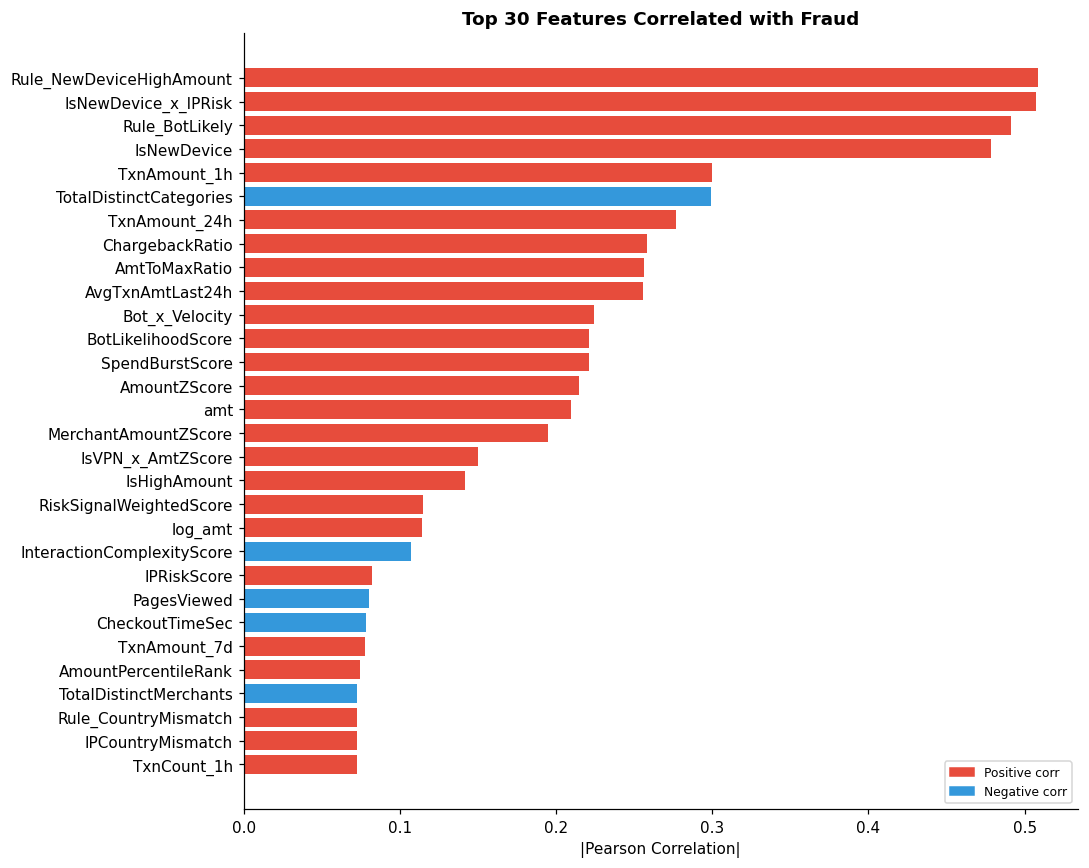

Top 30 correlations with is_fraud:
Rule_NewDeviceHighAmount      0.5087
IsNewDevice_x_IPRisk          0.5073
Rule_BotLikely                0.4913
IsNewDevice                   0.4782
TxnAmount_1h                  0.3001
TotalDistinctCategories      -0.2990
TxnAmount_24h                 0.2766
ChargebackRatio               0.2581
AmtToMaxRatio                 0.2561
AvgTxnAmtLast24h              0.2556
Bot_x_Velocity                0.2245
BotLikelihoodScore            0.2214
SpendBurstScore               0.2213
AmountZScore                  0.2148
amt                           0.2093
MerchantAmountZScore          0.1949
IsVPN_x_AmtZScore             0.1500
IsHighAmount                  0.1420
RiskSignalWeightedScore       0.1147
log_amt                       0.1143
InteractionComplexityScore   -0.1073
IPRiskScore                   0.0823
PagesViewed                  -0.0804
CheckoutTimeSec              -0.0785
TxnAmount_7d                  0.0777
AmountPercentileRank          0.0748
Tot

In [14]:
# Top features by absolute correlation with is_fraud
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["is_fraud","cc_num","unix_time"]]

corr = df[num_cols + ["is_fraud"]].corr()["is_fraud"].drop("is_fraud")
corr_sorted = corr.abs().sort_values(ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#e74c3c" if corr[i] > 0 else "#3498db" for i in corr_sorted.index]
ax.barh(corr_sorted.index[::-1], corr_sorted.values[::-1], color=colors[::-1])
ax.set_title("Top 30 Features Correlated with Fraud", fontweight="bold")
ax.set_xlabel("|Pearson Correlation|")

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#e74c3c", label="Positive corr"),
                   Patch(color="#3498db", label="Negative corr")], fontsize=8)
plt.tight_layout()
plt.show()

print("Top 30 correlations with is_fraud:")
print(corr.reindex(corr_sorted.index).round(4).to_string())

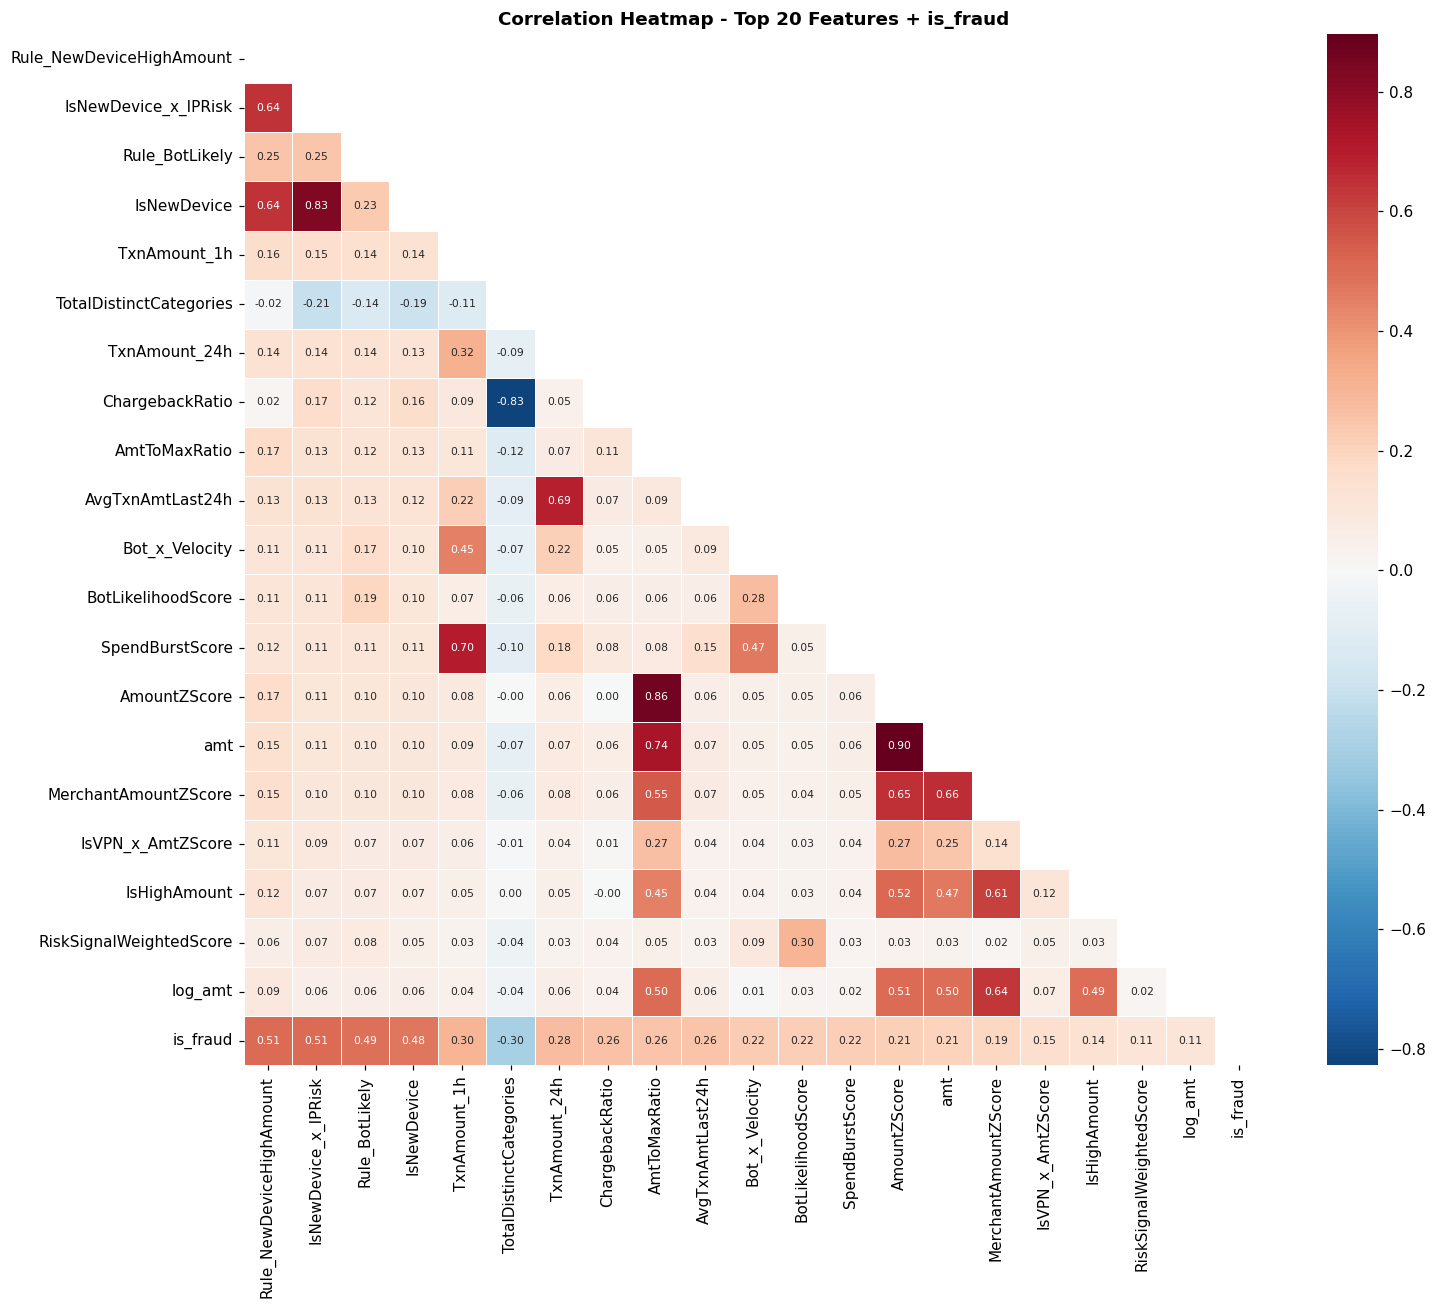

In [15]:
# Correlation heatmap - top 20 features + is_fraud
top20 = corr_sorted.head(20).index.tolist()
corr_matrix = df[top20 + ["is_fraud"]].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5, ax=ax, annot_kws={"size": 7})
ax.set_title("Correlation Heatmap - Top 20 Features + is_fraud", fontweight="bold")
plt.tight_layout()
plt.show()

In [16]:
# 6. CUSTOMER AND ACCOUNT PATTERNS

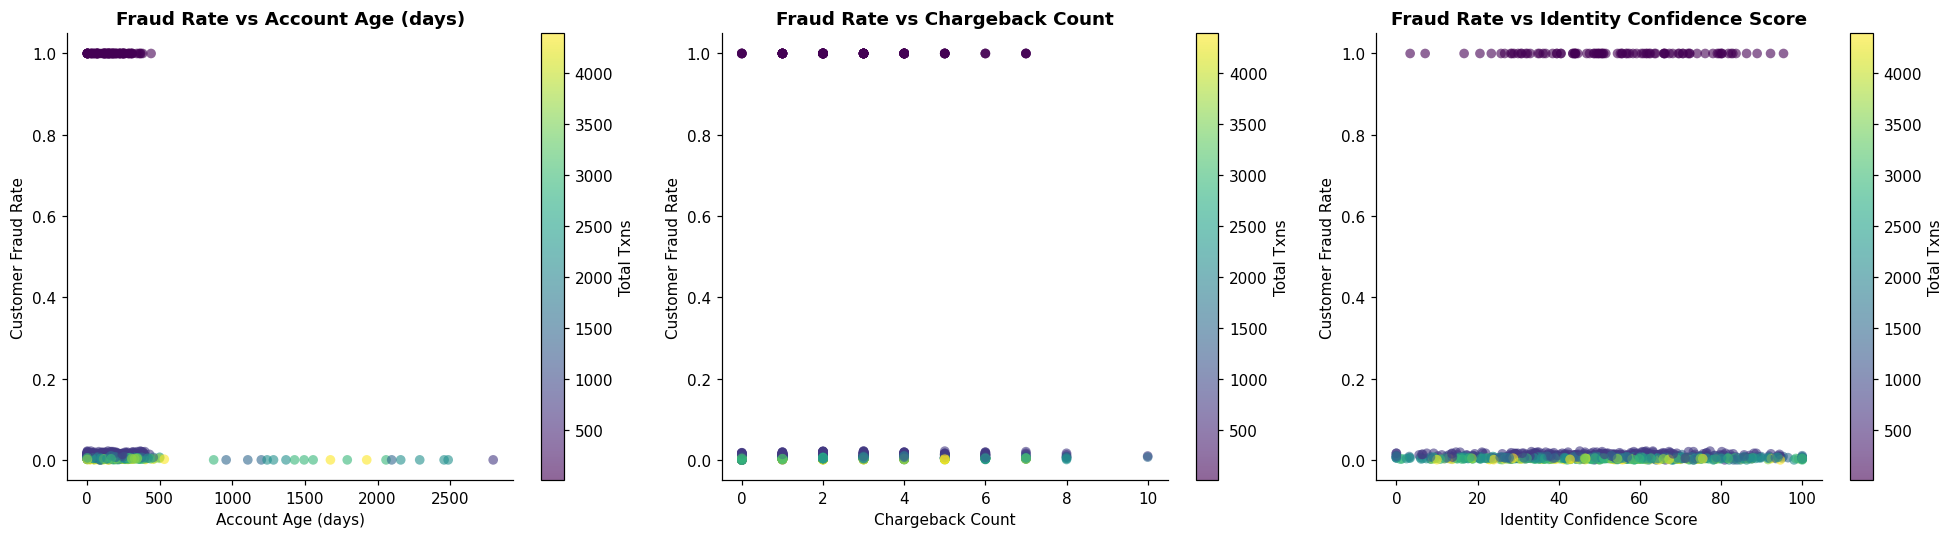

Customers with ANY fraud:  976 / 999
Customers with >5% fraud rate: 91

Fraud customer account age: mean=153d  vs legit mean=223d


In [17]:
# Per-customer fraud rate vs account age, chargeback count, identity score
cust = df.groupby("cc_num").agg(
    fraud_rate = ("is_fraud", "mean"),
    fraud_count = ("is_fraud", "sum"),
    total_txns = ("is_fraud", "count"),
    acct_age = ("AccountAgeDays", "first"),
    chargebacks = ("ChargebackCount", "first"),
    id_confidence = ("IdentityConfidenceScore", "first"),
    addr_consist = ("AddressConsistencyScore", "first"),
    prev_fraud_flag = ("PreviousFraudFlag", "first"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (x, xlabel) in zip(axes, [
  ("acct_age", "Account Age (days)"),
  ("chargebacks", "Chargeback Count"),
  ("id_confidence", "Identity Confidence Score"),
]):
    sc = ax.scatter(cust[x], cust["fraud_rate"],
                    c=cust["total_txns"], cmap="viridis",
                    alpha=0.6, s=40, edgecolors="none")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Customer Fraud Rate")
    ax.set_title(f"Fraud Rate vs {xlabel}", fontweight="bold")
    plt.colorbar(sc, ax=ax, label="Total Txns")

plt.tight_layout()
plt.show()

# How many customers have any fraud?
print(f"Customers with ANY fraud:  {(cust['fraud_count']>0).sum()} / {len(cust)}")
print(f"Customers with >5% fraud rate: {(cust['fraud_rate']>0.05).sum()}")
print(f"\nFraud customer account age: mean={cust[cust['prev_fraud_flag']==1]['acct_age'].mean():.0f}d  "
      f"vs legit mean={cust[cust['prev_fraud_flag']==0]['acct_age'].mean():.0f}d")

In [18]:
# 7. BUSINESS RULE EXTRACTION

In [19]:
def rule_stats(mask, label):
    """Compute precision, recall, lift, FPR for a boolean rule mask."""
    baseline = df["is_fraud"].mean()
    flagged = df[mask]
    tp = flagged["is_fraud"].sum()
    fp = (flagged["is_fraud"] == 0).sum()
    fn = df["is_fraud"].sum() - tp
    tn = (df["is_fraud"] == 0).sum() - fp
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    lift = prec / baseline if baseline > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    return {
        "Rule": label,
        "Flagged": int(mask.sum()),
        "Fraud caught (TP)": int(tp),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
        "Lift": round(lift, 2),
        "FPR (legit blocked)": round(fpr, 4),
    }

baseline = df["is_fraud"].mean()

rules = [
    # Single-signal rules
    rule_stats(df["IsTor"] == 1, "IsTor = 1"),
    rule_stats(df["IsVPN"] == 1, "IsVPN = 1"),
    rule_stats(df["IPCountryMismatch"] == 1, "IP Country Mismatch"),
    rule_stats(df["IsDisposableEmail"] == 1, "Disposable Email"),
    rule_stats(df["SyntheticIdentityFlag"] == 1, "Synthetic Identity"),
    rule_stats(df["PreviousFraudFlag"] == 1, "Previous Fraud Flag"),
    rule_stats(df["ImpossibleTravelFlag"] == 1, "Impossible Travel"),
    rule_stats(df["DeviceBlacklisted"] == 1, "Device Blacklisted"),
    rule_stats(df["IsVOIP"] == 1, "VOIP Phone"),
    rule_stats(df["ChargebackCount"] >= 3, "Chargebacks >= 3"),
    rule_stats(df["IsNewDevice"] == 1, "New Device"),
    rule_stats(df["BotLikelihoodScore"] >= 0.7, "Bot Score >= 0.7"),
    rule_stats(df["BotLikelihoodScore"] >= 0.9, "Bot Score >= 0.9"),
    rule_stats(df["AmountZScore"] >= 3.0, "Amount Z-Score >= 3"),
    rule_stats(df["AmountDeviation_30d"] >= 3.0, "30d Amount Dev >= 3"),
    rule_stats(df["SpendBurstScore"] >= 10, "Spend Burst >= 10"),
    rule_stats(df["IPRiskScore"] >= 70, "IP Risk >= 70"),
    rule_stats(df["IPRiskScore"] >= 85, "IP Risk >= 85"),
    rule_stats(df["AccountAgeDays"] <= 7, "Account Age <= 7d"),
    rule_stats(df["AccountAgeDays"] <= 30, "Account Age <= 30d"),
    rule_stats(df["SSNMatchScore"] <= 0.4, "SSN Match <= 0.4"),
    rule_stats(df["RiskSignalCount"] >= 3, "Risk Signal Count >= 3"),
    rule_stats(df["RiskSignalCount"] >= 5, "Risk Signal Count >= 5"),
    # Combination rules
    rule_stats((df["IsVPN"]==1) & (df["IsNewDevice"]==1), "VPN + New Device"),
    rule_stats((df["IsVPN"]==1) & (df["AmountZScore"]>=2), "VPN + High Amount"),
    rule_stats((df["IsNewDevice"]==1) & (df["AmountZScore"]>=2), "New Device + High Amount"),
    rule_stats((df["IPCountryMismatch"]==1) & (df["IsNewDevice"]==1), "Country Mismatch + New Device"),
    rule_stats((df["BotLikelihoodScore"]>=0.7) & (df["IsNewDevice"]==1), "Bot + New Device"),
    rule_stats((df["IsDisposableEmail"]==1) & (df["AccountAgeDays"]<=30), "Disposable Email + New Account"),
    rule_stats((df["SyntheticIdentityFlag"]==1) & (df["ChargebackCount"]>=1), "Synthetic ID + Any Chargeback"),
    rule_stats((df["IsTor"]==1) | (df["IsVPN"]==1) | (df["IPCountryMismatch"]==1), "TOR or VPN or Country Mismatch"),
    rule_stats((df["RiskSignalCount"]>=3) & (df["AmountZScore"]>=2), "Risk Count>=3 + High Amount"),
    rule_stats((df["BotLikelihoodScore"]>=0.7) & (df["SpendBurstScore"]>=5), "Bot + Spend Burst>=5"),
]

rules_df = pd.DataFrame(rules).sort_values("Lift", ascending=False)
rules_df.index = range(1, len(rules_df)+1)
print(f"Baseline fraud rate: {baseline:.4%}\n")
rules_df

Baseline fraud rate: 0.5210%



,Rule,Flagged,Fraud caught (TP),Precision,Recall,F1,Lift,FPR (legit blocked)
1,Bot Score >= 0.9,576,576,1.0000,0.0597,0.1126,191.9400,0.0000
2,Bot + New Device,1033,1032,0.9990,0.1069,0.1932,191.7500,0.0000
3,Bot + Spend Burst>=5,907,898,0.9901,0.0930,0.1701,190.0300,0.0000
4,New Device + High Amount,2329,2262,0.9712,0.2344,0.3776,186.4200,0.0000
5,Bot Score >= 0.7,2512,2424,0.9650,0.2512,0.3986,185.2100,0.0000
6,Country Mismatch + New Device,1716,1443,0.8409,0.1495,0.2539,161.4000,0.0001
7,VPN + New Device,1111,861,0.7750,0.0892,0.1600,148.7500,0.0001
8,New Device,7840,4181,0.5333,0.4332,0.4781,102.3600,0.0020
9,Risk Count>=3 + High Amount,9083,2884,0.3175,0.2988,0.3079,60.9400,0.0034
10,VPN + High Amount,3831,1121,0.2926,0.1162,0.1663,56.1600,0.0015


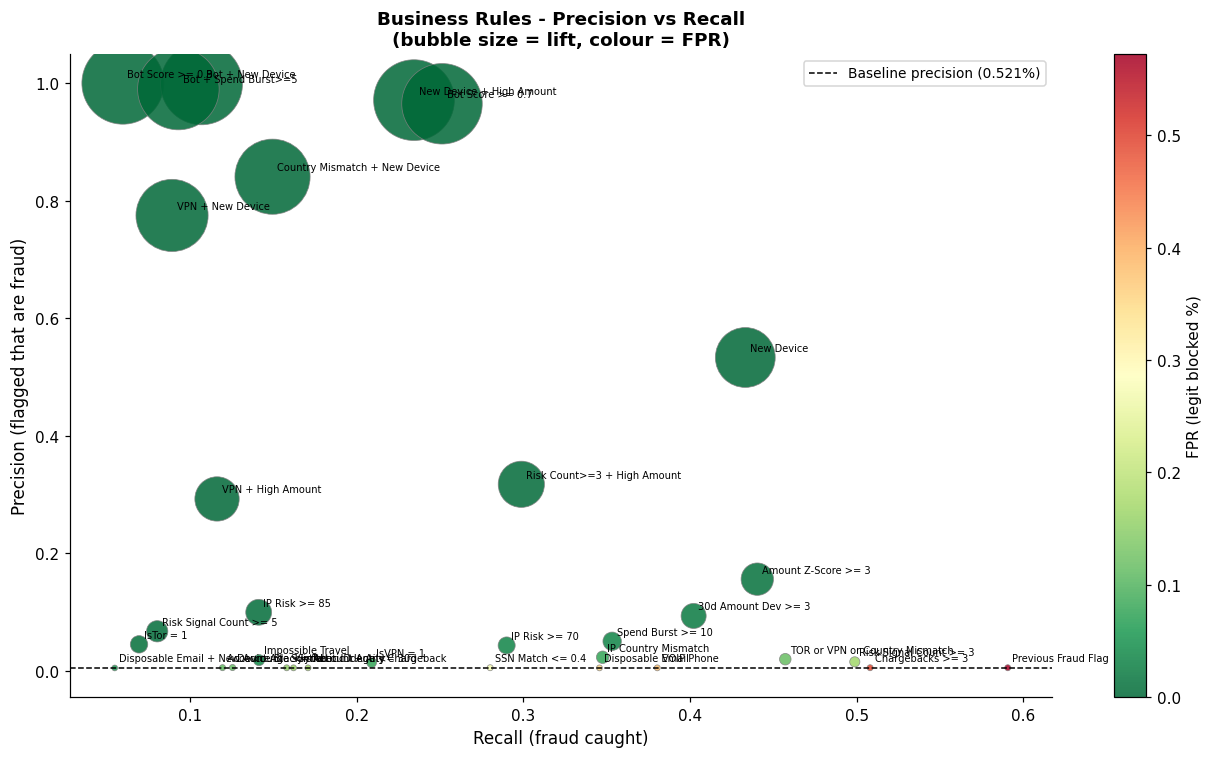

In [20]:
# Precision vs Recall scatter
fig, ax = plt.subplots(figsize=(12, 7))

sc = ax.scatter(
    rules_df["Recall"],
    rules_df["Precision"],
    s=rules_df["Lift"] * 15,
    c=rules_df["FPR (legit blocked)"],
    cmap="RdYlGn_r",
    alpha=0.85,
    edgecolors="grey",
    linewidth=0.5,
)
plt.colorbar(sc, ax=ax, label="FPR (legit blocked %)")
ax.axhline(baseline, color="black", linestyle="--", linewidth=1, label=f"Baseline precision ({baseline:.3%})")

for _, row in rules_df.iterrows():
    ax.annotate(row["Rule"], (row["Recall"], row["Precision"]), fontsize=6.5, ha="left", va="bottom", xytext=(3, 3), textcoords="offset points")

ax.set_xlabel("Recall (fraud caught)", fontsize=11)
ax.set_ylabel("Precision (flagged that are fraud)", fontsize=11)
ax.set_title("Business Rules - Precision vs Recall\n(bubble size = lift, colour = FPR)", fontweight="bold", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [21]:
# 8. FINAL BUSINESS RULES

In [22]:
DECLINE_RULES = [
    "IsTor = 1",
    "Synthetic Identity",
    "Bot Score >= 0.9",
    "Synthetic ID + Any Chargeback",
    "VPN + New Device",
    "Risk Signal Count >= 5",
]
REVIEW_RULES = [
    "IsVPN = 1",
    "IP Country Mismatch",
    "Impossible Travel",
    "Disposable Email",
    "Bot Score >= 0.7",
    "Chargebacks >= 3",
    "Country Mismatch + New Device",
    "Bot + New Device",
    "30d Amount Dev >= 3",
    "Risk Signal Count >= 3",
    "Disposable Email + New Account",
]
MONITOR_RULES = [
    "Account Age <= 7d",
    "VOIP Phone",
    "New Device",
    "IP Risk >= 70",
    "SSN Match <= 0.4",
    "Spend Burst >= 10",
]

def action_label(rule):
    if rule in DECLINE_RULES: return "DECLINE"
    if rule in REVIEW_RULES: return "REVIEW"
    return "MONITOR"

ACTION_COLORS = {"DECLINE": "#e74c3c", "REVIEW": "#f39c12", "MONITOR": "#3498db"}

summary = rules_df[rules_df["Rule"].isin(DECLINE_RULES + REVIEW_RULES + MONITOR_RULES)].copy()
summary["Action"] = summary["Rule"].map(action_label)
summary["Precision%"] = (summary["Precision"] * 100).round(2)
summary["Recall%"] = (summary["Recall"] * 100).round(2)
summary["FPR%"] = (summary["FPR (legit blocked)"] * 100).round(3)
summary = summary[["Action","Rule","Flagged","Fraud caught (TP)","Precision%","Recall%","Lift","FPR%","F1"]]
summary = summary.sort_values(["Action","Lift"], ascending=[True, False])
summary = summary.reset_index(drop=True)

# Styled table
styled = (summary.style
    .apply(lambda col: [f"background-color: {ACTION_COLORS.get(v,'white')}; color: white" if col.name == "Action" else "" for v in col], axis=0)
    .format({"Precision%": "{:.2f}%", 
             "Recall%": "{:.2f}%",
             "FPR%": "{:.3f}%", 
             "Lift": "{:.1f}x", 
             "F1": "{:.4f}"}))

print("Recommended Business Rules by Action Tier: " + str(len(summary)))
styled

Recommended Business Rules by Action Tier: 23


,Action,Rule,Flagged,Fraud caught (TP),Precision%,Recall%,Lift,FPR%,F1
0,DECLINE,Bot Score >= 0.9,576,576,100.00%,5.97%,191.9x,0.000%,0.1126
1,DECLINE,VPN + New Device,1111,861,77.50%,8.92%,148.8x,0.010%,0.1600
2,DECLINE,Risk Signal Count >= 5,11506,775,6.74%,8.03%,12.9x,0.580%,0.0733
3,DECLINE,IsTor = 1,14816,670,4.52%,6.94%,8.7x,0.770%,0.0548
4,DECLINE,Synthetic ID + Any Chargeback,287613,1525,0.53%,15.80%,1.0x,15.530%,0.0103
5,DECLINE,Synthetic Identity,299310,1564,0.52%,16.21%,1.0x,16.160%,0.0101
6,MONITOR,New Device,7840,4181,53.33%,43.32%,102.4x,0.200%,0.4781
7,MONITOR,Spend Burst >= 10,67597,3410,5.04%,35.33%,9.7x,3.480%,0.0883
8,MONITOR,IP Risk >= 70,64634,2799,4.33%,29.00%,8.3x,3.360%,0.0754
9,MONITOR,Account Age <= 7d,210105,1153,0.55%,11.95%,1.1x,11.340%,0.0105


RULE COVERAGE SUMMARY
------------------------------------------------------------
Total fraud: 9,651

DECLINE tier catches: 3,328 (34.5% of all fraud)
Legit transactions blocked: 312,614 (16.965% FPR)

REVIEW tier catches: 5,803 (60.1% of all fraud)
Legit sent to review: 1,103,595 (59.889% of legit)

Fraud missed by rules: 520 (5.4%) -> send to ML model

Combined rule recall: 94.6%


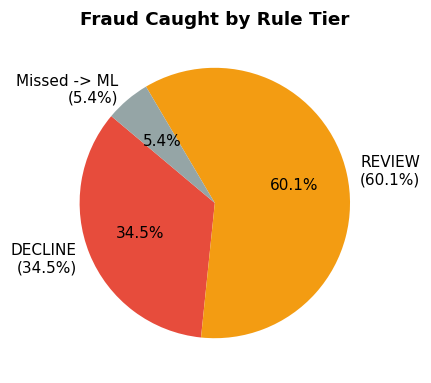

In [23]:
# Coverage Summary
decline_mask = (
  (df["IsTor"] == 1) |
  (df["SyntheticIdentityFlag"] == 1) |
  (df["BotLikelihoodScore"] >= 0.9) |
  ((df["SyntheticIdentityFlag"] == 1) & (df["ChargebackCount"] >= 1)) |
  ((df["IsVPN"] == 1) & (df["IsNewDevice"] == 1)) |
  (df["RiskSignalCount"] >= 5)
)

review_mask = (
  (df["IsVPN"] == 1) |
  (df["IPCountryMismatch"] == 1) |
  (df["ImpossibleTravelFlag"] == 1) |
  (df["IsDisposableEmail"] == 1) |
  (df["BotLikelihoodScore"] >= 0.7) |
  (df["ChargebackCount"] >= 3) |
  ((df["IPCountryMismatch"] == 1) & (df["IsNewDevice"] == 1)) |
  ((df["BotLikelihoodScore"] >= 0.7) & (df["IsNewDevice"] == 1)) |
  (df["AmountDeviation_30d"] >= 3.0) |
  (df["RiskSignalCount"] >= 3) |
  ((df["IsDisposableEmail"] == 1) & (df["AccountAgeDays"] <= 30))
)

review_only_mask = review_mask & ~decline_mask

total_fraud = df["is_fraud"].sum()

d_fraud = df[decline_mask & (df["is_fraud"]==1)].shape[0]
r_fraud = df[review_only_mask & (df["is_fraud"]==1)].shape[0]
m_fraud = total_fraud - d_fraud - r_fraud

d_legit = df[decline_mask & (df["is_fraud"]==0)].shape[0]
r_legit = df[review_only_mask & (df["is_fraud"]==0)].shape[0]





print("RULE COVERAGE SUMMARY")
print("-" * 60)
print(f"Total fraud: {total_fraud:,}")
print()
print(f"DECLINE tier catches: {d_fraud:,} ({d_fraud/total_fraud:.1%} of all fraud)")
print(f"Legit transactions blocked: {d_legit:,} ({d_legit/len(legit):.3%} FPR)")
print()
print(f"REVIEW tier catches: {r_fraud:,} ({r_fraud/total_fraud:.1%} of all fraud)")
print(f"Legit sent to review: {r_legit:,} ({r_legit/len(legit):.3%} of legit)")
print()
print(f"Fraud missed by rules: {m_fraud:,} ({m_fraud/total_fraud:.1%}) -> send to ML model")
print()
print(f"Combined rule recall: {(d_fraud+r_fraud)/total_fraud:.1%}")


# Pie chart
fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(
    [d_fraud, r_fraud, m_fraud],
    labels=[f"DECLINE\n({d_fraud/total_fraud:.1%})", f"REVIEW\n({r_fraud/total_fraud:.1%})", f"Missed -> ML\n({m_fraud/total_fraud:.1%})"],
    colors=["#e74c3c","#f39c12","#95a5a6"],
    autopct="%1.1f%%", startangle=140,
)
ax.set_title("Fraud Caught by Rule Tier", fontweight="bold")

plt.tight_layout()
plt.show()